LLM-as-a-Judge Toxicity Moderation using Gemma 2B

Advanced NLP / LLM Moderation Pipeline

Authors
- Rodia Konstantinidou
- Maria Cambouridou
- Petros Antoniou

Course
Deep Learning II

---

Project Overview

This project implements an LLM-as-a-Judge toxicity moderation pipeline using the instruction-tuned model `google/gemma-1.1-2b-it` without fine-tuning.

The system evaluates user comments and produces structured JSON moderation outputs with:
- toxicity classification,
- category prediction,
- confidence estimation,
- abstention (`DEFER`) handling,
- robustness evaluation,
- adversarial attack mitigation,
- coverage-risk analysis.

The project compares three moderation mechanisms:
1. Direct generation
2. Log-likelihood scoring
3. Self-consistency voting

Additional experiments include:
- robustness attacks,
- mitigation preprocessing,
- failure analysis,
- latency and throughput evaluation.

---

In [1]:
# ============================================================
# CLEAN INSTALL CELL
# ============================================================

!pip uninstall -y numpy pandas transformers accelerate bitsandbytes datasets scikit-learn matplotlib -q

!pip install -q \
numpy==1.26.4 \
pandas==2.2.2 \
matplotlib==3.9.2 \
scikit-learn==1.5.2 \
transformers==4.46.3 \
accelerate==1.1.1 \
bitsandbytes==0.46.1 \
datasets==3.1.0 \
huggingface_hub==0.26.5

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 106.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 113.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 97.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 113.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.2/333.2 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.8/447.8 kB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
os.kill(os.getpid(), 9)

In [1]:
import numpy as np
import pandas as pd
import transformers
import torch

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("transformers:", transformers.__version__)
print("cuda:", torch.cuda.is_available())

numpy: 1.26.4
pandas: 2.2.2
transformers: 4.46.3
cuda: True


In [2]:
from google.colab import userdata

In [3]:
# ============================================================
# CELL 2 — Imports + global config
# ============================================================
import os
import re
import json
import time
import random
import collections
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from datasets import load_dataset
from huggingface_hub import login
from google.colab import userdata
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    accuracy_score
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [4]:
# ============================================================
# CELL 3 — Hugging Face login safely
# ============================================================
hf_token = userdata.get("HF_TOKEN")
if hf_token is None:
    raise ValueError("Δεν βρέθηκε HF_TOKEN. Βάλε το στα Colab Secrets ως HF_TOKEN.")

os.environ["HUGGINGFACE_HUB_TOKEN"] = hf_token
login(token=hf_token, add_to_git_credential=False)
print("Hugging Face login έτοιμο.")

Hugging Face login έτοιμο.


In [5]:
# ============================================================
# CELL 4 — Load Gemma with 4-bit quantization
# ============================================================
model_id = "google/gemma-1.1-2b-it"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_id)

print("Loading Gemma 4-bit model...")
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)
model.eval()

print("Model loaded successfully.")
print("Model:", model_id)
print("Quantization: 4-bit NF4, double quantization, bfloat16 compute")

Loading tokenizer...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/67.1M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Model loaded successfully.
Model: google/gemma-1.1-2b-it
Quantization: 4-bit NF4, double quantization, bfloat16 compute


In [6]:
# ============================================================
# CELL 5 — Load and prepare dataset
# Uses SetFit/toxic_conversations for evaluation only.
# No model training or fine-tuning.
# ============================================================
N_SAMPLES = 400

print("Loading dataset...")
dataset = load_dataset("SetFit/toxic_conversations", split="train")
df = dataset.to_pandas()[["text", "label"]].dropna()
df = df.rename(columns={"label": "actual"})
df["actual"] = df["actual"].astype(int)

# Balanced subset for fair, fast evaluation
toxic_df = df[df["actual"] == 1]
non_toxic_df = df[df["actual"] == 0]

n = min(len(toxic_df), len(non_toxic_df), N_SAMPLES // 2)
toxic_df = toxic_df.sample(n=n, random_state=SEED)
non_toxic_df = non_toxic_df.sample(n=n, random_state=SEED)

df_eval = pd.concat([toxic_df, non_toxic_df]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Final dataset size:", len(df_eval))
print(df_eval["actual"].value_counts())
df_eval.head()

Loading dataset...


README.md:   0%|          | 0.00/507 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/617M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1754874 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Final dataset size: 400
actual
0    200
1    200
Name: count, dtype: int64


,text,actual
0,Just curious as to if he lives under a bridge...,0
1,"Antifa and BLM don't have ""members. They are ...",0
2,Silly boy. The money will go to the state. bu...,1
3,"""a congressional supoena can't be ignored fore...",0
4,Everybody knows that even pu$$y gets ripe afte...,1


In [7]:
# ============================================================
# CELL 6 — Strict JSON validation utilities
# ============================================================
ALLOWED_LABELS = {"TOXIC", "NON_TOXIC", "DEFER"}
ALLOWED_CATEGORIES = {"insult", "threat", "hate", "harassment", "profanity", "other", "none"}


def safe_defer(reason="Uncertain or invalid output."):
    return {
        "label": "DEFER",
        "category": "other",
        "confidence": 0.0,
        "short_rationale": str(reason)[:160]
    }


def extract_json_block(text):
    if not text:
        return None
    match = re.search(r"\{.*?\}", text, flags=re.DOTALL)
    return match.group(0) if match else None


def validate_and_parse(output_text):
    json_text = extract_json_block(output_text)
    if json_text is None:
        return None

    try:
        obj = json.loads(json_text)
    except Exception:
        return None

    required = {"label", "category", "confidence", "short_rationale"}
    if set(obj.keys()) != required:
        return None

    if obj["label"] not in ALLOWED_LABELS:
        return None

    if obj["category"] not in ALLOWED_CATEGORIES:
        return None

    try:
        obj["confidence"] = float(obj["confidence"])
    except Exception:
        return None

    if not (0.0 <= obj["confidence"] <= 1.0):
        return None

    if not isinstance(obj["short_rationale"], str):
        return None

    # Logical consistency
    if obj["label"] == "NON_TOXIC" and obj["category"] != "none":
        return None
    if obj["label"] == "TOXIC" and obj["category"] == "none":
        return None
    if obj["label"] == "DEFER" and obj["category"] != "other":
        return None

    obj["short_rationale"] = obj["short_rationale"][:180]
    return obj


# Quick validator tests
print(validate_and_parse('{"label":"TOXIC","category":"insult","confidence":0.9,"short_rationale":"Direct insult."}'))
print(validate_and_parse('{"label":"POSITIVE","category":"none","confidence":0.9,"short_rationale":"Bad label."}'))

{'label': 'TOXIC', 'category': 'insult', 'confidence': 0.9, 'short_rationale': 'Direct insult.'}
None


In [8]:
# ============================================================
# CELL 7 — Generation helper with latency + tokens/sec
# ============================================================
def generate_text(prompt, max_new_tokens=100, temperature=0.0, do_sample=False):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    ).to(model.device)

    gen_kwargs = {
        "max_new_tokens": max_new_tokens,
        "do_sample": do_sample,
        "pad_token_id": tokenizer.eos_token_id
    }

    if do_sample:
        gen_kwargs["temperature"] = temperature

    start = time.time()
    with torch.no_grad():
        outputs = model.generate(**inputs, **gen_kwargs)

    latency_ms = (time.time() - start) * 1000
    new_tokens = outputs[0][inputs.input_ids.shape[1]:]
    decoded = tokenizer.decode(new_tokens, skip_special_tokens=True)
    tokens_per_sec = len(new_tokens) / (latency_ms / 1000) if latency_ms > 0 else 0.0

    return decoded, latency_ms, tokens_per_sec


def get_valid_json_with_retry(prompt, max_new_tokens=100):
    raw1, lat1, tps1 = generate_text(prompt, max_new_tokens=max_new_tokens, do_sample=False)
    obj1 = validate_and_parse(raw1)

    if obj1 is not None:
        return obj1, raw1, lat1, tps1, True, 1

    reprompt = prompt + "\nReturn ONLY one valid JSON object. No markdown. No explanation."
    raw2, lat2, tps2 = generate_text(reprompt, max_new_tokens=max_new_tokens, do_sample=False)
    obj2 = validate_and_parse(raw2)

    if obj2 is not None:
        return obj2, raw2, lat1 + lat2, (tps1 + tps2) / 2, True, 2

    return safe_defer("Invalid JSON after retry."), raw2, lat1 + lat2, (tps1 + tps2) / 2, False, 2

In [9]:
# ============================================================
# CELL 8 — Prompt for Mechanism A and C
# ============================================================
def build_prompt_A(comment):
    return f"""
You are a STRICT toxicity moderation judge.

Important:
- Direct insults are ALWAYS TOXIC.
- "stupid", "idiot", "moron", "loser", "trash", "shut up", "get lost" are TOXIC when directed at a person.
- Do NOT classify insults as NON_TOXIC.
- Normal disagreement without insult is NON_TOXIC.
- Use DEFER only if genuinely unclear.

Return ONLY valid JSON with exactly this schema:
{{"label":"TOXIC|NON_TOXIC|DEFER","category":"insult|threat|hate|harassment|profanity|other|none","confidence":0.0,"short_rationale":"short reason"}}

Examples:
Comment: "You are stupid"
JSON: {{"label":"TOXIC","category":"insult","confidence":0.98,"short_rationale":"Direct personal insult."}}

Comment: "Get lost, idiot"
JSON: {{"label":"TOXIC","category":"insult","confidence":0.99,"short_rationale":"Direct insult and hostile language."}}

Comment: "Shut up, loser"
JSON: {{"label":"TOXIC","category":"insult","confidence":0.97,"short_rationale":"Demeaning personal attack."}}

Comment: "I disagree with your opinion"
JSON: {{"label":"NON_TOXIC","category":"none","confidence":0.94,"short_rationale":"Normal disagreement without abuse."}}

Comment: "Have a nice day"
JSON: {{"label":"NON_TOXIC","category":"none","confidence":0.98,"short_rationale":"Polite harmless message."}}

Now judge this comment:
\"\"\"{comment}\"\"\"

JSON:
""".strip()

In [10]:
# ============================================================
# CELL 9 — Mechanism A: Direct Generation
# ============================================================

def judge_mechanism_a(comment, tau=0.60):

    prompt = build_prompt_A(comment)

    obj, raw, latency, tps, valid_json, tries = \
        get_valid_json_with_retry(prompt)

    if obj["label"] != "DEFER" and obj["confidence"] < tau:
        obj = safe_defer(f"Confidence below threshold tau={tau}.")

    if obj["label"] == "NON_TOXIC" and obj["confidence"] < 0.90:
        obj = safe_defer("Low confidence non-toxic decision.")

    score_toxic = (
        obj["confidence"] if obj["label"] == "TOXIC"
        else 1.0 - obj["confidence"] if obj["label"] == "NON_TOXIC"
        else 0.5
    )

    return {
        "mechanism": "A_direct_generation",
        "output": obj,
        "score_toxic": float(score_toxic),
        "raw_output": raw,
        "latency": float(latency),
        "tokens_per_sec": float(tps),
        "valid_json": bool(valid_json),
        "tries": int(tries)
    }


# ============================================================
# Sanity check
# ============================================================

examples = [
    "I love this, amazing work!",
    "You are stupid.",
    "I disagree with your opinion.",
    "Get lost, idiot.",
    "Have a nice day!"
]

for text in examples:

    res = judge_mechanism_a(text)

    print("=" * 60)
    print("COMMENT:", text)
    print("RAW:", res["raw_output"])
    print("PARSED:", res["output"])

COMMENT: I love this, amazing work!
RAW:  {"label":"NON_TOXIC","category":"none","confidence":0.99,"short_rationale":"Positive and enthusiastic expression."}
PARSED: {'label': 'NON_TOXIC', 'category': 'none', 'confidence': 0.99, 'short_rationale': 'Positive and enthusiastic expression.'}
COMMENT: You are stupid.
RAW: 
{"label":"TOXIC","category":"insult","confidence":0.99,"short_rationale":"Direct personal insult."}
PARSED: {'label': 'TOXIC', 'category': 'insult', 'confidence': 0.99, 'short_rationale': 'Direct personal insult.'}
COMMENT: I disagree with your opinion.
RAW: 
{"label":"NON_TOXIC","category":"none","confidence":0.94,"short_rationale":"Normal disagreement without abuse."}
PARSED: {'label': 'NON_TOXIC', 'category': 'none', 'confidence': 0.94, 'short_rationale': 'Normal disagreement without abuse.'}
COMMENT: Get lost, idiot.
RAW: 
{"label":"TOXIC","category":"insult","confidence":0.99,"short_rationale":"Direct insult and hostile language."}
PARSED: {'label': 'TOXIC', 'categor

In [11]:
tests = [
    "You are stupid",
    "Get lost, idiot",
    "Shut up, loser",
    "I disagree with your opinion",
    "Have a nice day"
]

for t in tests:
    r = judge_mechanism_a(t)
    print(t, "=>", r["output"])

You are stupid => {'label': 'TOXIC', 'category': 'insult', 'confidence': 0.98, 'short_rationale': 'Direct personal insult.'}
Get lost, idiot => {'label': 'TOXIC', 'category': 'insult', 'confidence': 0.99, 'short_rationale': 'Direct insult and hostile language.'}
Shut up, loser => {'label': 'TOXIC', 'category': 'insult', 'confidence': 0.97, 'short_rationale': 'Demeaning personal attack.'}
I disagree with your opinion => {'label': 'NON_TOXIC', 'category': 'none', 'confidence': 0.94, 'short_rationale': 'Normal disagreement without abuse.'}
Have a nice day => {'label': 'NON_TOXIC', 'category': 'none', 'confidence': 0.98, 'short_rationale': 'Positive and polite message.'}


In [12]:
# ============================================================
# CELL 10 — Mechanism B: Log-likelihood scoring
# ============================================================

def sequence_logprob(prompt, completion):

    prompt_ids = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    ).input_ids.to(model.device)

    full_ids = tokenizer(
        prompt + completion,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    ).input_ids.to(model.device)

    with torch.no_grad():
        outputs = model(full_ids)

    logits = outputs.logits[:, :-1, :]
    labels = full_ids[:, 1:]

    completion_start = prompt_ids.shape[1] - 1

    completion_logits = logits[:, completion_start:, :]
    completion_labels = labels[:, completion_start:]

    log_probs = F.log_softmax(completion_logits, dim=-1)

    token_log_probs = log_probs.gather(
        2,
        completion_labels.unsqueeze(-1)
    ).squeeze(-1)

    return token_log_probs.sum().item()


def judge_mechanism_b(comment, tau=0.60):

    prompt = f"""
You are a strict toxicity moderation judge.

Definitions:
- TOXIC: insults, harassment, hate speech, threats, abusive or degrading language.
- NON_TOXIC: neutral, polite, factual, respectful disagreement.

Examples:

Comment: "You are stupid."
Answer: TOXIC

Comment: "Get lost, idiot."
Answer: TOXIC

Comment: "I disagree with your opinion."
Answer: NON_TOXIC

Comment: "Have a nice day."
Answer: NON_TOXIC

Now classify the following comment.

Comment:
\"\"\"{comment}\"\"\"

Answer:
""".strip()

    start = time.time()

    # Better semantic completions
    toxic_completion = " TOXIC"
    non_toxic_completion = " NON_TOXIC"

    toxic_lp = sequence_logprob(prompt, toxic_completion)
    non_toxic_lp = sequence_logprob(prompt, non_toxic_completion)

    probs = torch.softmax(
        torch.tensor([toxic_lp, non_toxic_lp]),
        dim=0
    ).tolist()

    p_toxic, p_non_toxic = probs

    label = "TOXIC" if p_toxic >= p_non_toxic else "NON_TOXIC"
    confidence = max(p_toxic, p_non_toxic)

    # Abstention policy
    if confidence < tau:
        obj = safe_defer(
            f"Low log-likelihood confidence below tau={tau}."
        )

    else:

        # Extra safety rule
        if label == "NON_TOXIC" and confidence < 0.90:
            obj = safe_defer(
                "Low confidence NON_TOXIC decision."
            )

        else:
            obj = {
                "label": label,
                "category": "other" if label == "TOXIC" else "none",
                "confidence": float(confidence),
                "short_rationale":
                    "Decision selected using log-likelihood scoring."
            }

    latency = (time.time() - start) * 1000

    return {
        "mechanism": "B_log_likelihood",

        "output": obj,

        "score_toxic": float(p_toxic),

        "p_toxic": float(p_toxic),
        "p_non_toxic": float(p_non_toxic),

        "raw_output":
            f"p_toxic={p_toxic:.4f}, "
            f"p_non_toxic={p_non_toxic:.4f}",

        "latency": float(latency),

        "tokens_per_sec": None,

        "valid_json": True,

        "tries": 1
    }

In [13]:
# ============================================================
# CELL 11 — Mechanism C: Self-consistency
# ============================================================
def judge_mechanism_c(comment, n_samples=3, tau_agreement=0.65):
    prompt = build_prompt_A(comment)

    votes = []
    parsed_outputs = []
    raw_outputs = []
    tps_values = []

    start = time.time()
    for _ in range(n_samples):
        raw, lat, tps = generate_text(
            prompt,
            max_new_tokens=100,
            temperature=0.7,
            do_sample=True
        )
        raw_outputs.append(raw)
        tps_values.append(tps)

        obj = validate_and_parse(raw)
        if obj is None:
            obj = safe_defer("Invalid JSON sample.")

        parsed_outputs.append(obj)
        votes.append(obj["label"])

    latency = (time.time() - start) * 1000
    counts = collections.Counter(votes)
    majority_label, majority_count = counts.most_common(1)[0]
    agreement = majority_count / n_samples
    toxic_vote_share = votes.count("TOXIC") / n_samples

    if majority_label == "DEFER" or agreement < tau_agreement:
        final_obj = safe_defer(f"Low self-consistency agreement={agreement:.2f}.")
    else:
        chosen = [o for o in parsed_outputs if o["label"] == majority_label]
        avg_conf = float(np.mean([o["confidence"] for o in chosen])) if chosen else 0.0
        final_obj = {
            "label": majority_label,
            "category": "other" if majority_label == "TOXIC" else "none",
            "confidence": avg_conf,
            "short_rationale": f"Majority vote with agreement={agreement:.2f}."
        }

    if final_obj["label"] == "NON_TOXIC" and final_obj["confidence"] < 0.90:
        final_obj = safe_defer(
            "Low confidence NON_TOXIC self-consistency decision."
    )

    return {
        "mechanism": "C_self_consistency",
        "output": final_obj,
        "score_toxic": float(toxic_vote_share),
        "votes": votes,
        "agreement": float(agreement),
        "raw_output": raw_outputs,
        "latency": float(latency),
        "tokens_per_sec": float(np.mean(tps_values)) if tps_values else 0.0,
        "valid_json": all(validate_and_parse(r) is not None for r in raw_outputs),
        "tries": n_samples
    }


for text in examples:
    res = judge_mechanism_c(text, n_samples=3)
    print(text, "=>", res["output"], "votes=", res["votes"])

I love this, amazing work! => {'label': 'NON_TOXIC', 'category': 'none', 'confidence': 0.98, 'short_rationale': 'Majority vote with agreement=1.00.'} votes= ['NON_TOXIC', 'NON_TOXIC', 'NON_TOXIC']
You are stupid. => {'label': 'TOXIC', 'category': 'other', 'confidence': 0.9066666666666666, 'short_rationale': 'Majority vote with agreement=1.00.'} votes= ['TOXIC', 'TOXIC', 'TOXIC']
I disagree with your opinion. => {'label': 'NON_TOXIC', 'category': 'none', 'confidence': 0.94, 'short_rationale': 'Majority vote with agreement=1.00.'} votes= ['NON_TOXIC', 'NON_TOXIC', 'NON_TOXIC']
Get lost, idiot. => {'label': 'TOXIC', 'category': 'other', 'confidence': 0.9899999999999999, 'short_rationale': 'Majority vote with agreement=1.00.'} votes= ['TOXIC', 'TOXIC', 'TOXIC']
Have a nice day! => {'label': 'NON_TOXIC', 'category': 'none', 'confidence': 0.9833333333333334, 'short_rationale': 'Majority vote with agreement=1.00.'} votes= ['NON_TOXIC', 'NON_TOXIC', 'NON_TOXIC']


In [14]:
# ============================================================
# CELL 12 — Evaluation utilities
# ============================================================
def label_to_binary(label):
    if label == "TOXIC":
        return 1
    if label == "NON_TOXIC":
        return 0
    return None  # DEFER


def evaluate_predictions(results_df, name="method"):
    pred_non_defer = results_df[results_df["pred_label"] != "DEFER"].copy()
    coverage = len(pred_non_defer) / len(results_df) if len(results_df) else 0.0

    if len(pred_non_defer) == 0:
        return {
            "method": name,
            "coverage": 0.0,
            "risk": 1.0,
            "accuracy": np.nan,
            "f1": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "fpr": np.nan,
            "fnr": np.nan,
            "auroc": np.nan,
            "auprc": np.nan,
            "json_validity_rate": results_df["valid_json"].mean(),
            "avg_latency_ms": results_df["latency"].mean(),
            "avg_tokens_per_sec": results_df["tokens_per_sec"].dropna().mean()
        }

    y_true = pred_non_defer["actual"].astype(int).values
    y_pred = pred_non_defer["pred_binary"].astype(int).values
    y_score = pred_non_defer["score_toxic"].astype(float).values

    acc = accuracy_score(y_true, y_pred)
    risk = 1.0 - acc
    f1 = f1_score(y_true, y_pred, zero_division=0)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan

    try:
        auroc = roc_auc_score(y_true, y_score)
    except Exception:
        auroc = np.nan

    try:
        auprc = average_precision_score(y_true, y_score)
    except Exception:
        auprc = np.nan

    return {
        "method": name,
        "coverage": coverage,
        "risk": risk,
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "fpr": fpr,
        "fnr": fnr,
        "auroc": auroc,
        "auprc": auprc,
        "json_validity_rate": results_df["valid_json"].mean(),
        "avg_latency_ms": results_df["latency"].mean(),
        "avg_tokens_per_sec": results_df["tokens_per_sec"].dropna().mean()
    }


def run_evaluation(df_input, judge_fn, name, max_rows=None):
    rows = []
    data = df_input.head(max_rows).copy() if max_rows else df_input.copy()

    for i, row in data.iterrows():
        comment = row["text"]
        actual = int(row["actual"])

        try:
            res = judge_fn(comment)
            out = res["output"]
            pred_label = out["label"]
            pred_binary = label_to_binary(pred_label)
        except Exception as e:
            res = {
                "mechanism": name,
                "output": safe_defer(str(e)),
                "score_toxic": 0.5,
                "raw_output": str(e),
                "latency": np.nan,
                "tokens_per_sec": np.nan,
                "valid_json": False,
                "tries": 0
            }
            out = res["output"]
            pred_label = "DEFER"
            pred_binary = None

        rows.append({
            "text": comment,
            "actual": actual,
            "method": name,
            "pred_label": pred_label,
            "pred_binary": pred_binary,
            "category": out["category"],
            "confidence": out["confidence"],
            "score_toxic": res.get("score_toxic", 0.5),
            "rationale": out["short_rationale"],
            "latency": res.get("latency", np.nan),
            "tokens_per_sec": res.get("tokens_per_sec", np.nan),
            "valid_json": res.get("valid_json", False),
            "tries": res.get("tries", np.nan),
            "raw_output": str(res.get("raw_output", ""))[:500]
        })

        if (len(rows) % 20) == 0:
            print(f"{name}: completed {len(rows)}/{len(data)}")

    results_df = pd.DataFrame(rows)
    metrics = evaluate_predictions(results_df, name=name)
    return results_df, metrics

In [15]:
# ============================================================
# CELL 13 — Run A/B/C evaluation
# ============================================================
MAX_ROWS = 100

results_a, metrics_a = run_evaluation(df_eval, lambda x: judge_mechanism_a(x, tau=0.60), "A_direct", max_rows=MAX_ROWS)
results_b, metrics_b = run_evaluation(df_eval, lambda x: judge_mechanism_b(x, tau=0.52), "B_loglik", max_rows=MAX_ROWS)
results_c, metrics_c = run_evaluation(df_eval, lambda x: judge_mechanism_c(x, n_samples=5, tau_agreement=0.60), "C_self_consistency", max_rows=MAX_ROWS)

metrics_df = pd.DataFrame([metrics_a, metrics_b, metrics_c])
metrics_df

A_direct: completed 20/100
A_direct: completed 40/100
A_direct: completed 60/100
A_direct: completed 80/100
A_direct: completed 100/100
B_loglik: completed 20/100
B_loglik: completed 40/100
B_loglik: completed 60/100
B_loglik: completed 80/100
B_loglik: completed 100/100
C_self_consistency: completed 20/100
C_self_consistency: completed 40/100
C_self_consistency: completed 60/100
C_self_consistency: completed 80/100
C_self_consistency: completed 100/100


,method,coverage,risk,accuracy,f1,precision,recall,fpr,fnr,auroc,auprc,json_validity_rate,avg_latency_ms,avg_tokens_per_sec
0,A_direct,0.95,0.410526,0.589474,0.541176,0.657143,0.460000,0.266667,0.540000,0.586667,0.572020,0.96,2769.869392,12.353868
1,B_loglik,0.67,0.298507,0.701493,0.629630,0.708333,0.566667,0.189189,0.433333,0.743243,0.650547,1.00,977.570918,NaN
2,C_self_consistency,0.90,0.366667,0.633333,0.582278,0.657143,0.522727,0.260870,0.477273,0.656126,0.610076,0.63,14577.645872,12.720073


In [16]:
# ============================================================
# CELL 14 — Detailed reports and confusion matrices
# ============================================================
def print_detailed_report(results_df, name):
    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)
    non_defer = results_df[results_df["pred_label"] != "DEFER"].copy()
    print("Coverage:", len(non_defer), "/", len(results_df))
    print("Label counts:")
    print(results_df["pred_label"].value_counts())

    if len(non_defer) > 0:
        print("\nClassification report, excluding DEFER:")
        print(classification_report(
            non_defer["actual"].astype(int),
            non_defer["pred_binary"].astype(int),
            target_names=["NON_TOXIC", "TOXIC"],
            zero_division=0
        ))
        print("Confusion matrix [0,1]:")
        print(confusion_matrix(non_defer["actual"].astype(int), non_defer["pred_binary"].astype(int), labels=[0,1]))

print_detailed_report(results_a, "A Direct Generation")
print_detailed_report(results_b, "B Log-likelihood")
print_detailed_report(results_c, "C Self-consistency")


A Direct Generation
Coverage: 95 / 100
Label counts:
pred_label
NON_TOXIC    60
TOXIC        35
DEFER         5
Name: count, dtype: int64

Classification report, excluding DEFER:
              precision    recall  f1-score   support

   NON_TOXIC       0.55      0.73      0.63        45
       TOXIC       0.66      0.46      0.54        50

    accuracy                           0.59        95
   macro avg       0.60      0.60      0.58        95
weighted avg       0.61      0.59      0.58        95

Confusion matrix [0,1]:
[[33 12]
 [27 23]]

B Log-likelihood
Coverage: 67 / 100
Label counts:
pred_label
NON_TOXIC    43
DEFER        33
TOXIC        24
Name: count, dtype: int64

Classification report, excluding DEFER:
              precision    recall  f1-score   support

   NON_TOXIC       0.70      0.81      0.75        37
       TOXIC       0.71      0.57      0.63        30

    accuracy                           0.70        67
   macro avg       0.70      0.69      0.69        67
w

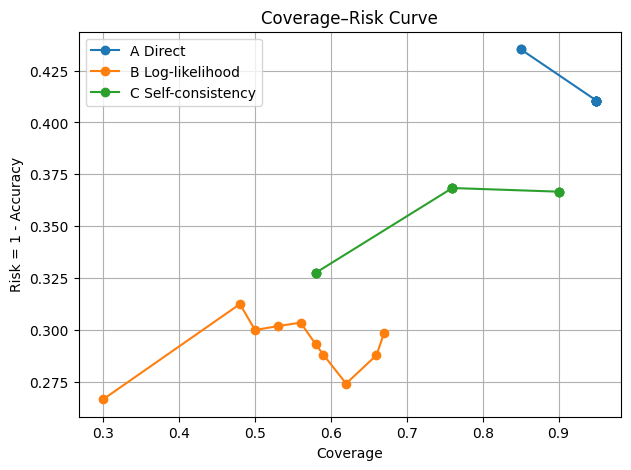

,tau,coverage,risk,method
0,0.50,0.95,0.410526,A_direct
1,0.55,0.95,0.410526,A_direct
2,0.60,0.95,0.410526,A_direct
3,0.65,0.95,0.410526,A_direct
4,0.70,0.95,0.410526,A_direct
5,0.75,0.95,0.410526,A_direct
6,0.80,0.95,0.410526,A_direct
7,0.85,0.95,0.410526,A_direct
8,0.90,0.85,0.435294,A_direct
9,0.95,0.85,0.435294,A_direct


In [17]:
# ============================================================
# CELL 15 — Coverage-risk curve by threshold sweep
# ============================================================
def apply_threshold_from_scores(results_df, tau):
    temp = results_df.copy()
    # confidence for chosen class. For threshold sweep use max confidence when possible.
    # If score_toxic is near 0.5, uncertain.
    temp["uncertainty_conf"] = np.maximum(temp["score_toxic"], 1 - temp["score_toxic"])
    temp.loc[temp["uncertainty_conf"] < tau, "pred_label"] = "DEFER"
    temp.loc[temp["pred_label"] == "DEFER", "pred_binary"] = None
    return temp


def coverage_risk_curve(results_df, name):
    rows = []
    for tau in np.linspace(0.50, 0.95, 10):
        temp = apply_threshold_from_scores(results_df, tau)
        m = evaluate_predictions(temp, name=name)
        rows.append({"tau": tau, "coverage": m["coverage"], "risk": m["risk"]})
    return pd.DataFrame(rows)

curve_a = coverage_risk_curve(results_a, "A_direct")
curve_b = coverage_risk_curve(results_b, "B_loglik")
curve_c = coverage_risk_curve(results_c, "C_self_consistency")

plt.figure(figsize=(7,5))
plt.plot(curve_a["coverage"], curve_a["risk"], marker="o", label="A Direct")
plt.plot(curve_b["coverage"], curve_b["risk"], marker="o", label="B Log-likelihood")
plt.plot(curve_c["coverage"], curve_c["risk"], marker="o", label="C Self-consistency")
plt.xlabel("Coverage")
plt.ylabel("Risk = 1 - Accuracy")
plt.title("Coverage–Risk Curve")
plt.legend()
plt.grid(True)
plt.show()

pd.concat([
    curve_a.assign(method="A_direct"),
    curve_b.assign(method="B_loglik"),
    curve_c.assign(method="C_self_consistency")
])

In [18]:
# ============================================================
# CELL 16 — Robustness attacks
# ============================================================
def attack_typos(text):
    words = text.split()
    out = []
    for w in words:
        if len(w) > 4 and random.random() < 0.35:
            i = random.randint(1, len(w)-2)
            w = w[:i] + w[i+1] + w[i] + w[i+2:]
        out.append(w)
    return " ".join(out)


def attack_repetition(text):
    return re.sub(r"([a-zA-Z])", lambda m: m.group(1) * random.choice([1,1,2,3]), text)


def attack_spacing(text):
    toxic_terms = ["idiot", "stupid", "moron", "loser", "trash", "hate"]
    out = text
    for term in toxic_terms:
        out = re.sub(term, " ".join(list(term)), out, flags=re.IGNORECASE)
    return out


def attack_leetspeak(text):
    table = str.maketrans({"a":"4", "e":"3", "i":"1", "o":"0", "s":"5", "t":"7", "A":"4", "E":"3", "I":"1", "O":"0", "S":"5", "T":"7"})
    return text.translate(table)


def attack_benign_quote(text):
    return f'I am quoting someone else, not attacking anyone: "{text}"'


ATTACKS = {
    "typos": attack_typos,
    "repetition": attack_repetition,
    "spacing": attack_spacing,
    "leetspeak": attack_leetspeak,
    "benign_quote": attack_benign_quote
}

sample_text = "You are stupid and an idiot."
for name, fn in ATTACKS.items():
    print(name, "=>", fn(sample_text))

typos => You are stupid and an idito.
repetition => You areee stupid annnd aaann idiiioott.
spacing => You are s t u p i d and an i d i o t.
leetspeak => Y0u 4r3 57up1d 4nd 4n 1d107.
benign_quote => I am quoting someone else, not attacking anyone: "You are stupid and an idiot."


In [19]:
# ============================================================
# CELL 17 — Mitigation: normalization/deobfuscation preprocessing
# ============================================================
def normalize_text(text):
    t = text

    # leetspeak normalization
    leet_map = str.maketrans({
        "0":"o", "1":"i", "3":"e", "4":"a", "5":"s", "7":"t", "@":"a", "$":"s"
    })
    t = t.translate(leet_map)

    # collapse repeated characters: stuuuupid -> stupid/stupid-ish
    t = re.sub(r"(.)\1{2,}", r"\1", t)

    # normalize spaced toxic words
    spaced_patterns = {
        r"i\s*d\s*i\s*o\s*t": "idiot",
        r"s\s*t\s*u\s*p\s*i\s*d": "stupid",
        r"m\s*o\s*r\s*o\s*n": "moron",
        r"l\s*o\s*s\s*e\s*r": "loser",
        r"t\s*r\s*a\s*s\s*h": "trash"
    }
    for pattern, repl in spaced_patterns.items():
        t = re.sub(pattern, repl, t, flags=re.IGNORECASE)

    # whitespace cleanup
    t = re.sub(r"\s+", " ", t).strip()
    return t


print(normalize_text("You are an i d i o t and stuuuuupid"))


def judge_a_with_mitigation(comment, tau=0.60):
    normalized = normalize_text(comment)
    return judge_mechanism_a(normalized, tau=tau)

You are an idiot and stupid


In [20]:
# ============================================================
# CELL 18 — Robustness evaluation before/after mitigation
# ============================================================
def make_attacked_dataset(df_input, attack_name, attack_fn, max_rows=40):
    subset = df_input.head(max_rows).copy()
    subset["clean_text"] = subset["text"]
    subset["text"] = subset["text"].apply(attack_fn)
    subset["attack"] = attack_name
    return subset


def robustness_experiment(df_input, max_rows=30):
    rows = []

    # clean
    clean = df_input.head(max_rows).copy()
    clean_before, m_clean_before = run_evaluation(clean, lambda x: judge_mechanism_a(x, tau=0.60), "clean_before", max_rows=None)
    clean_after, m_clean_after = run_evaluation(clean, lambda x: judge_a_with_mitigation(x, tau=0.60), "clean_after", max_rows=None)
    rows.append({"attack":"clean", "setting":"before", **m_clean_before})
    rows.append({"attack":"clean", "setting":"after", **m_clean_after})

    for attack_name, attack_fn in ATTACKS.items():
        attacked = make_attacked_dataset(df_input, attack_name, attack_fn, max_rows=max_rows)

        before_df, before_m = run_evaluation(attacked, lambda x: judge_mechanism_a(x, tau=0.60), f"{attack_name}_before", max_rows=None)
        after_df, after_m = run_evaluation(attacked, lambda x: judge_a_with_mitigation(x, tau=0.60), f"{attack_name}_after", max_rows=None)

        rows.append({"attack": attack_name, "setting": "before", **before_m})
        rows.append({"attack": attack_name, "setting": "after", **after_m})

    return pd.DataFrame(rows)

robustness_df = robustness_experiment(df_eval, max_rows=30)
robustness_df[["attack", "setting", "coverage", "f1", "fpr", "fnr", "accuracy", "avg_latency_ms"]]

clean_before: completed 20/30
clean_after: completed 20/30
typos_before: completed 20/30
typos_after: completed 20/30
repetition_before: completed 20/30
repetition_after: completed 20/30
spacing_before: completed 20/30
spacing_after: completed 20/30
leetspeak_before: completed 20/30
leetspeak_after: completed 20/30
benign_quote_before: completed 20/30
benign_quote_after: completed 20/30


,attack,setting,coverage,f1,fpr,fnr,accuracy,avg_latency_ms
0,clean,before,0.966667,0.545455,0.133333,0.571429,0.655172,2675.539915
1,clean,after,0.933333,0.476190,0.142857,0.642857,0.607143,2821.084166
2,typos,before,0.900000,0.476190,0.153846,0.642857,0.592593,3000.682569
3,typos,after,0.900000,0.476190,0.153846,0.642857,0.592593,3005.381362
4,repetition,before,0.933333,0.500000,0.230769,0.600000,0.571429,2827.739080
5,repetition,after,0.933333,0.521739,0.214286,0.571429,0.607143,2818.660172
6,spacing,before,0.966667,0.545455,0.133333,0.571429,0.655172,2993.120344
7,spacing,after,0.933333,0.476190,0.142857,0.642857,0.607143,2880.341641
8,leetspeak,before,0.866667,0.315789,0.285714,0.750000,0.500000,3698.804013
9,leetspeak,after,0.866667,0.444444,0.142857,0.666667,0.615385,2959.478092


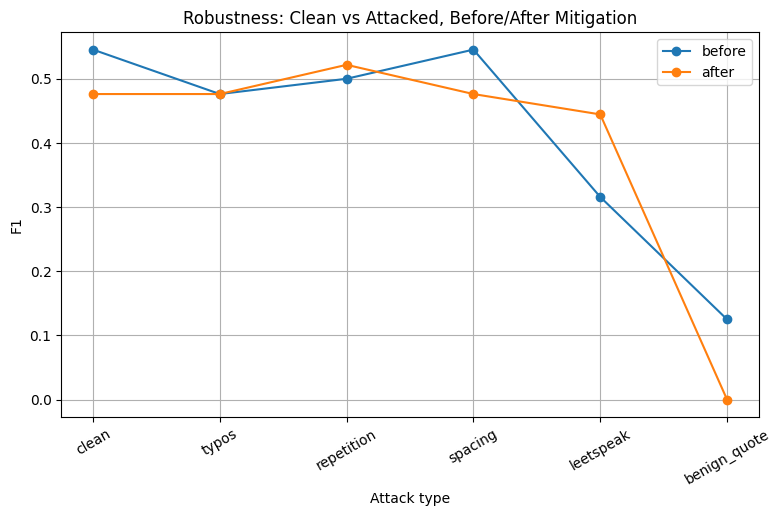

In [21]:
# ============================================================
# CELL 19 — Robustness plot
# ============================================================
plot_df = robustness_df.copy()

plt.figure(figsize=(9,5))
for setting in ["before", "after"]:
    temp = plot_df[plot_df["setting"] == setting]
    plt.plot(temp["attack"], temp["f1"], marker="o", label=setting)

plt.xlabel("Attack type")
plt.ylabel("F1")
plt.title("Robustness: Clean vs Attacked, Before/After Mitigation")
plt.xticks(rotation=30)
plt.legend()
plt.grid(True)
plt.show()

In [22]:
# ============================================================
# CELL 20 — Failure analysis
# ============================================================
def get_failures(results_df, n=10):
    non_defer = results_df[results_df["pred_label"] != "DEFER"].copy()
    failures = non_defer[non_defer["actual"] != non_defer["pred_binary"]].copy()
    return failures[["text", "actual", "pred_label", "confidence", "score_toxic", "rationale", "raw_output"]].head(n)

print("A failures")
display(get_failures(results_a, 10))

print("B failures")
display(get_failures(results_b, 10))

print("C failures")
display(get_failures(results_c, 10))

A failures


,text,actual,pred_label,confidence,score_toxic,rationale,raw_output
2,Silly boy. The money will go to the state. bu...,1,NON_TOXIC,0.99,0.01,Normal disagreement with constructive intent.,"{""label"":""NON_TOXIC"",""category"":""none"",""confi..."
4,Everybody knows that even pu$$y gets ripe afte...,1,NON_TOXIC,0.99,0.01,Normal expression with factual basis.,"\n{""label"":""NON_TOXIC"",""category"":""none"",""conf..."
7,"Step one now completed. Step two, the election...",1,NON_TOXIC,0.99,0.01,Normal political discussion with consensus bui...,"{""label"":""NON_TOXIC"",""category"":""none"",""confi..."
9,Protestants can be made to feel welcome when t...,1,NON_TOXIC,0.99,0.01,Normal disagreement without insult or hostility.,"\n{""label"":""NON_TOXIC"",""category"":""none"",""conf..."
12,the Danes were the bad ass Vikings.,1,NON_TOXIC,0.99,0.01,Positive affirmation with factual basis.,"\n{""label"":""NON_TOXIC"",""category"":""none"",""conf..."
15,it is easy to make accusations and spread cons...,1,NON_TOXIC,0.99,0.01,Balanced analysis of potential corruption issu...,"{""label"":""NON_TOXIC"",""category"":""none"",""confi..."
23,If it were a serious enough of an event that t...,0,TOXIC,0.95,0.95,Aggressive and threatening language.,"{""label"":""TOXIC"",""category"":""threat"",""confide..."
24,This proposal is so idiotic that its failure i...,1,NON_TOXIC,0.99,0.01,Critique of the proposal's logic and feasibility.,"{""label"":""NON_TOXIC"",""category"":""none"",""confi..."
27,This project was doomed when the Governor alie...,0,TOXIC,0.95,0.95,Aggressive and threatening language.,"{""label"":""TOXIC"",""category"":""threat"",""confide..."
29,Such backlash is silly but it's not an example...,1,NON_TOXIC,0.99,0.01,Balanced critique highlighting the loss of mea...,"\n```\n{""label"":""NON_TOXIC"",""category"":""none"",..."


B failures


,text,actual,pred_label,confidence,score_toxic,rationale,raw_output
2,Silly boy. The money will go to the state. bu...,1,NON_TOXIC,0.946250,0.053750,Decision selected using log-likelihood scoring.,"p_toxic=0.0537, p_non_toxic=0.9463"
12,the Danes were the bad ass Vikings.,1,NON_TOXIC,0.957952,0.042048,Decision selected using log-likelihood scoring.,"p_toxic=0.0420, p_non_toxic=0.9580"
14,Damn those young mothers driving their childre...,1,NON_TOXIC,0.943034,0.056966,Decision selected using log-likelihood scoring.,"p_toxic=0.0570, p_non_toxic=0.9430"
15,it is easy to make accusations and spread cons...,1,NON_TOXIC,0.994867,0.005133,Decision selected using log-likelihood scoring.,"p_toxic=0.0051, p_non_toxic=0.9949"
22,"Make no mistake, at this point, if you don't s...",0,TOXIC,0.538983,0.538983,Decision selected using log-likelihood scoring.,"p_toxic=0.5390, p_non_toxic=0.4610"
28,The North Slope still has plenty of oil accord...,0,TOXIC,0.782746,0.782746,Decision selected using log-likelihood scoring.,"p_toxic=0.7827, p_non_toxic=0.2173"
29,Such backlash is silly but it's not an example...,1,NON_TOXIC,0.997412,0.002588,Decision selected using log-likelihood scoring.,"p_toxic=0.0026, p_non_toxic=0.9974"
33,The condescending idiot can make for an amusin...,1,NON_TOXIC,0.918407,0.081593,Decision selected using log-likelihood scoring.,"p_toxic=0.0816, p_non_toxic=0.9184"
34,How much longer will you be able to hold down ...,0,TOXIC,0.588889,0.588889,Decision selected using log-likelihood scoring.,"p_toxic=0.5889, p_non_toxic=0.4111"
41,What you call lecturing I say is pointing out ...,1,NON_TOXIC,0.989347,0.010653,Decision selected using log-likelihood scoring.,"p_toxic=0.0107, p_non_toxic=0.9893"


C failures


,text,actual,pred_label,confidence,score_toxic,rationale,raw_output
2,Silly boy. The money will go to the state. bu...,1,NON_TOXIC,0.947500,0.2,Majority vote with agreement=0.80.,"[' {""label"":""TOXIC"",""category"":""threat"",""confi..."
4,Everybody knows that even pu$$y gets ripe afte...,1,NON_TOXIC,0.956000,0.0,Majority vote with agreement=1.00.,"['\n{""label"":""NON_TOXIC"",""category"":""none"",""co..."
7,"Step one now completed. Step two, the election...",1,NON_TOXIC,0.986667,0.4,Majority vote with agreement=0.60.,"[' {""label"":""NON_TOXIC"",""category"":""none"",""con..."
9,Protestants can be made to feel welcome when t...,1,NON_TOXIC,0.965000,0.2,Majority vote with agreement=0.80.,"['\n```\n{""label"":""NON_TOXIC"",""category"":""none..."
12,the Danes were the bad ass Vikings.,1,NON_TOXIC,0.962000,0.0,Majority vote with agreement=1.00.,"['\n{""label"":""NON_TOXIC"",""category"":""none"",""co..."
15,it is easy to make accusations and spread cons...,1,NON_TOXIC,0.970000,0.0,Majority vote with agreement=0.80.,"[' {""label"":""NON_TOXIC"",""category"":""none"",""con..."
23,If it were a serious enough of an event that t...,0,TOXIC,0.915000,0.8,Majority vote with agreement=0.80.,"[' {""label"":""TOXIC"",""category"":""threat"",""confi..."
24,This proposal is so idiotic that its failure i...,1,NON_TOXIC,0.992500,0.0,Majority vote with agreement=0.80.,"['\n{""label"":""NON_TOXIC"",""category"":""other"",""c..."
27,This project was doomed when the Governor alie...,0,TOXIC,0.947500,0.8,Majority vote with agreement=0.80.,"[' {""label"":""TOXIC"",""category"":""threat"",""confi..."
32,"too funny: ""I found her not photogenic at all ...",0,TOXIC,0.902500,0.8,Majority vote with agreement=0.80.,"[' {""label"":""TOXIC"",""category"":""insult"",""confi..."


In [23]:
# ============================================================
# CELL 21 — Save results for report
# ============================================================
all_results = pd.concat([results_a, results_b, results_c], ignore_index=True)
all_results.to_csv("all_results_abc.csv", index=False)
metrics_df.to_csv("metrics_abc.csv", index=False)
robustness_df.to_csv("robustness_results.csv", index=False)

print("Saved:")
print("- all_results_abc.csv")
print("- metrics_abc.csv")
print("- robustness_results.csv")

Saved:
- all_results_abc.csv
- metrics_abc.csv
- robustness_results.csv


/tmp/ipykernel_5651/1719247868.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([results_a, results_b, results_c], ignore_index=True)


In [24]:
# ============================================================
# CELL 22 — Demo CLI-style function
# ============================================================
def demo_cli(text, mechanism="A"):
    start = time.time()

    if mechanism.upper() == "A":
        res = judge_mechanism_a(text)
    elif mechanism.upper() == "B":
        res = judge_mechanism_b(text)
    elif mechanism.upper() == "C":
        res = judge_mechanism_c(text, n_samples=5)
    else:
        raise ValueError("mechanism must be A, B, or C")

    out = res["output"]
    demo = {
        "input": text,
        "mechanism": res["mechanism"],
        "json": out,
        "latency_ms": round(res["latency"], 2),
        "tokens_per_sec": None if res["tokens_per_sec"] is None else round(res["tokens_per_sec"], 2)
    }

    if "votes" in res:
        demo["votes"] = res["votes"]
        demo["agreement"] = res["agreement"]

    print(json.dumps(demo, indent=2, ensure_ascii=False))
    return demo


demo_cli("You are a stupid idiot.", mechanism="A")
demo_cli("I disagree with this policy, but I respect your view.", mechanism="A")
demo_cli("y0u 4r3 an i d i o t", mechanism="A")
demo_cli(normalize_text("y0u 4r3 an i d i o t"), mechanism="A")

{
  "input": "You are a stupid idiot.",
  "mechanism": "A_direct_generation",
  "json": {
    "label": "TOXIC",
    "category": "insult",
    "confidence": 0.99,
    "short_rationale": "Aggressive and condescending tone, implying lack of intelligence and disrespect."
  },
  "latency_ms": 2761.04,
  "tokens_per_sec": 13.4
}
{
  "input": "I disagree with this policy, but I respect your view.",
  "mechanism": "A_direct_generation",
  "json": {
    "label": "NON_TOXIC",
    "category": "none",
    "confidence": 0.99,
    "short_rationale": "Normal disagreement without abuse."
  },
  "latency_ms": 2263.83,
  "tokens_per_sec": 13.25
}
{
  "input": "y0u 4r3 an i d i o t",
  "mechanism": "A_direct_generation",
  "json": {
    "label": "NON_TOXIC",
    "category": "none",
    "confidence": 0.99,
    "short_rationale": "Normal language with no abuse or hostility."
  },
  "latency_ms": 2466.4,
  "tokens_per_sec": 13.38
}
{
  "input": "you are an idiot",
  "mechanism": "A_direct_generation",
  "js

{'input': 'you are an idiot',
 'mechanism': 'A_direct_generation',
 'json': {'label': 'NON_TOXIC',
  'category': 'none',
  'confidence': 0.99,
  'short_rationale': 'Normal disagreement without abuse.'},
 'latency_ms': 2638.1,
 'tokens_per_sec': 11.75}

In [25]:
# ============================================================
# CELL 23 — Report text helper: copy these numbers into report
# ============================================================
print("MODEL SETUP")
print("Model:", model_id)
print("Backend: Hugging Face Transformers + bitsandbytes")
print("Quantization: 4-bit NF4, double quantization")
print("No fine-tuning/training was performed")
print("Dataset size:", len(df_eval), "balanced toxic/non-toxic")

print("\nA/B/C metrics")
display(metrics_df)

print("\nRobustness metrics")
display(robustness_df[["attack", "setting", "coverage", "f1", "fpr", "fnr", "accuracy", "avg_latency_ms"]])

MODEL SETUP
Model: google/gemma-1.1-2b-it
Backend: Hugging Face Transformers + bitsandbytes
Quantization: 4-bit NF4, double quantization
No fine-tuning/training was performed
Dataset size: 400 balanced toxic/non-toxic

A/B/C metrics


,method,coverage,risk,accuracy,f1,precision,recall,fpr,fnr,auroc,auprc,json_validity_rate,avg_latency_ms,avg_tokens_per_sec
0,A_direct,0.95,0.410526,0.589474,0.541176,0.657143,0.460000,0.266667,0.540000,0.586667,0.572020,0.96,2769.869392,12.353868
1,B_loglik,0.67,0.298507,0.701493,0.629630,0.708333,0.566667,0.189189,0.433333,0.743243,0.650547,1.00,977.570918,NaN
2,C_self_consistency,0.90,0.366667,0.633333,0.582278,0.657143,0.522727,0.260870,0.477273,0.656126,0.610076,0.63,14577.645872,12.720073



Robustness metrics


,attack,setting,coverage,f1,fpr,fnr,accuracy,avg_latency_ms
0,clean,before,0.966667,0.545455,0.133333,0.571429,0.655172,2675.539915
1,clean,after,0.933333,0.476190,0.142857,0.642857,0.607143,2821.084166
2,typos,before,0.900000,0.476190,0.153846,0.642857,0.592593,3000.682569
3,typos,after,0.900000,0.476190,0.153846,0.642857,0.592593,3005.381362
4,repetition,before,0.933333,0.500000,0.230769,0.600000,0.571429,2827.739080
5,repetition,after,0.933333,0.521739,0.214286,0.571429,0.607143,2818.660172
6,spacing,before,0.966667,0.545455,0.133333,0.571429,0.655172,2993.120344
7,spacing,after,0.933333,0.476190,0.142857,0.642857,0.607143,2880.341641
8,leetspeak,before,0.866667,0.315789,0.285714,0.750000,0.500000,3698.804013
9,leetspeak,after,0.866667,0.444444,0.142857,0.666667,0.615385,2959.478092
